# Tauc and Urbach Plot for Perovskite with and without CsI

In [31]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

1. Import a UV-VIS data

In [32]:
withCsI_file = ""  # Enter your file path/folder path in this place
withoutCsI_file = ""  # Enter your file path/folder path in this place
with_df = pd.read_csv(withCsI_file, sep=";")#, usecols = ["wavelength", "absorbance"])
without_df = pd.read_csv(withoutCsI_file, sep=";")

labels = ["Pervoskite with CsI", "Perovskite without CsI"]
colors = ["#3C4CFF", "#15EB52"]
colors_fit = ["#7883FD", "#ABFFC3"]


In [33]:
with_df

,nm,A
0,1100.0,0.085688
1,1095.0,0.085477
2,1090.0,0.086048
3,1085.0,0.087574
4,1080.0,0.088778
...,...,...
160,300.0,2.366227
161,295.0,1.534434
162,290.0,0.820353
163,285.0,1.241085


In [34]:
group_palette = {
    'R3000_20s': '#EB1615',  # blue
    'R3000_25s': '#EBBD15',  # brighter saturated orange
    'R5000_25s': '#35B85B',  # green
    'R5000_30s': '#3C4CFF',  # brighter saturated red
}

In [35]:
wavelength_with = np.array(with_df["nm"].tolist())
absorbance_with = np.array(with_df["A"].tolist())

wavelength_without = np.array(without_df["nm"].tolist())
absorbance_without = np.array(without_df["A"].tolist())

eV = 1240/wavelength_with
tauc_intensity = (eV * absorbance_with)**2
tauc_intensity_with = (eV * absorbance_with)**2
tauc_intensity_without = ((eV * absorbance_without)**2)

### Absorbance vs. Wavelength

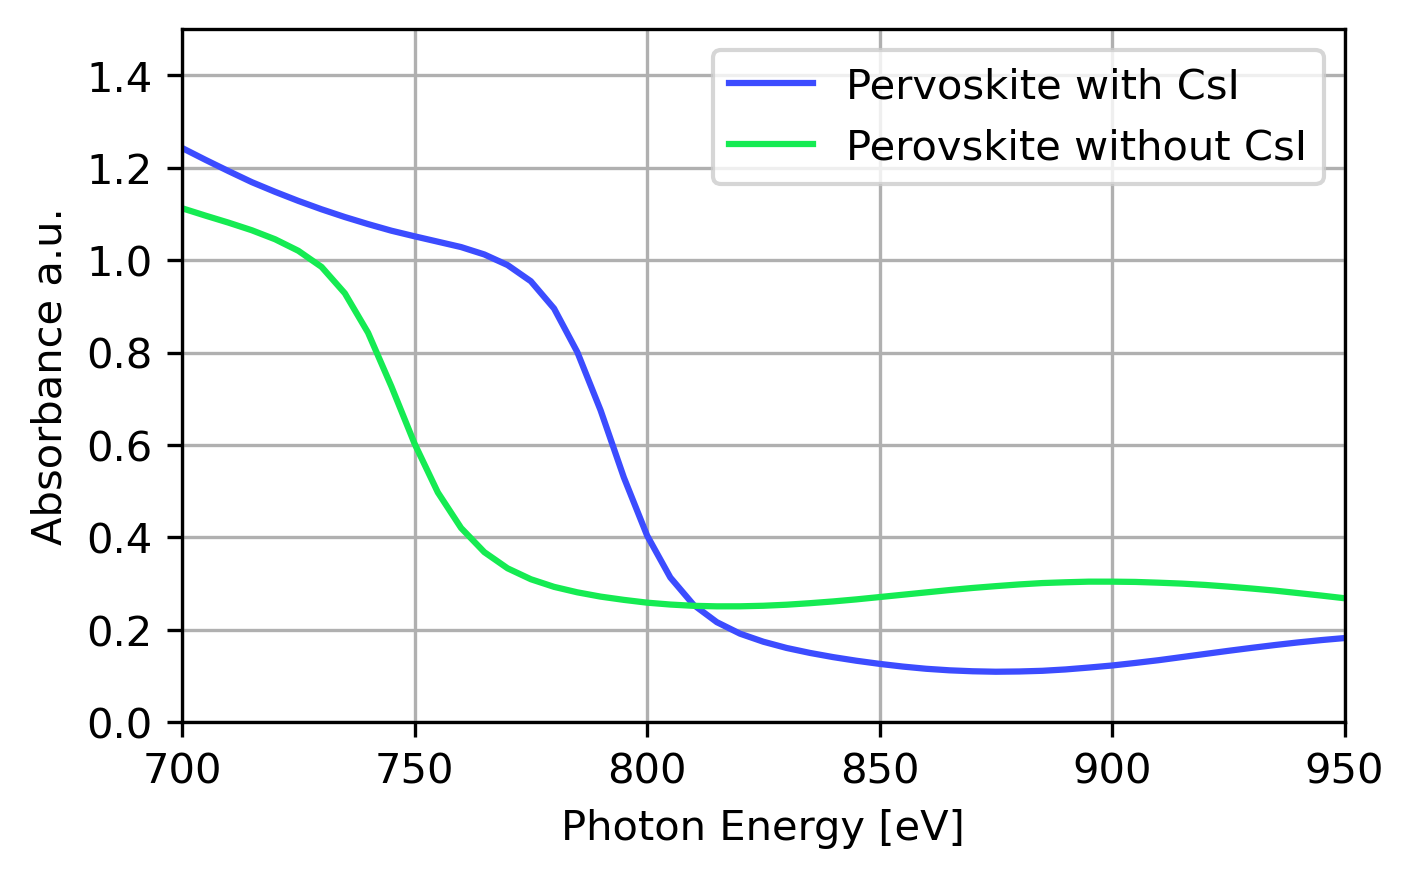

In [36]:
plt.figure(figsize = (5, 3), dpi =300)
plt.plot(wavelength_with, absorbance_with, label = labels[0], color = colors[0])
plt.plot(wavelength_without, absorbance_without, label = labels[1], color = colors[1])
plt.xlim(700, 950)
plt.ylim(0, 1.5)
plt.ylabel("Absorbance a.u.")
plt.xlabel("Photon Energy [eV]")
plt.legend()
plt.grid()

### Do a quick plot for the tauc plot

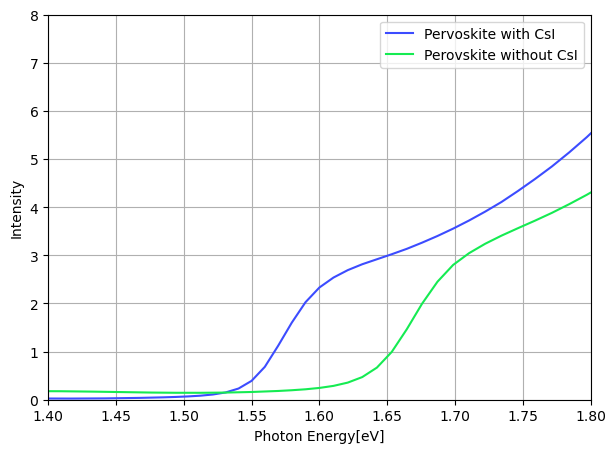

In [37]:
plt.figure(figsize = (7, 5))
plt.plot(eV, tauc_intensity_with, label = labels[0], color = colors[0])
plt.plot(eV, tauc_intensity_without,  label = labels[1], color = colors[1])
plt.ylim(0, 8)
plt.xlim(1.4, 1.8)
plt.xlabel("Photon Energy[eV]")
plt.ylabel(f"Intensity")
plt.grid()
plt.legend()

In [38]:
def tauc_fit_linear(x, y, x_min = 1.56, x_max = 1.59):
    """
    Perform a linear fit on the Tauc plot data within a given energy range.

    Parameters
    ----------
    x : array-like
        Photon energy values (in eV).
    y : array-like
        Corresponding Tauc intensity values ((αhν)^n).
    x_min : float
        Lower bound of the fitting region (eV).
    x_max : float
        Upper bound of the fitting region (eV).

    Returns
    -------
    results : dict
        {
            'slope': float,
            'intercept': float,
            'r_squared': float,
            'tauc_gap': float,   # x-intercept in eV
            'x_selected': np.ndarray,
            'y_selected': np.ndarray
        }
    """

    # Ensure numpy arrays and column vectors
    x = np.array(x).reshape(-1, 1)
    y = np.array(y).reshape(-1, 1)

    # Select fitting region
    mask = (x > x_min) & (x < x_max)
    x_selected = x[mask].reshape(-1, 1)
    y_selected = y[mask].reshape(-1, 1)

    # Perform linear regression
    model = LinearRegression().fit(x_selected, y_selected)
    slope = model.coef_[0, 0]
    intercept = model.intercept_[0]
    r_squared = model.score(x_selected, y_selected)
    tauc_gap = -intercept / slope

    # Print summary
    print(f"Slope: {slope:.4f}")
    print(f"Intercept: {intercept:.4f}")
    print(f"R²: {r_squared:.4f}")
    print(f"Tauc gap (x-intercept): {tauc_gap:.4f} eV")

    return {
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_squared,
        'tauc_gap': tauc_gap,
        'x_selected': x_selected,
        'y_selected': y_selected
    }

In [39]:
tauc_fit_with = tauc_fit_linear(eV, tauc_intensity_with)
bandgap_with = tauc_fit_with['tauc_gap']
tauc_fit_without = tauc_fit_linear(eV, tauc_intensity_without, x_min=1.64, x_max=1.67)
bandgap_without = tauc_fit_without['tauc_gap']
#print(bandgap_with, bandgap_without)
print(tauc_fit_with)

Slope: 44.8628
Intercept: -69.2848
R²: 0.9986
Tauc gap (x-intercept): 1.5444 eV
Slope: 36.1704
Intercept: -58.7620
R²: 0.9898
Tauc gap (x-intercept): 1.6246 eV
{'slope': 44.862778968722296, 'intercept': -69.28478092708158, 'r_squared': 0.9986209471799153, 'tauc_gap': 1.5443711361569012, 'x_selected': array([[1.56962025],
       [1.57961783],
       [1.58974359]]), 'y_selected': array([[1.12299918],
       [1.60063421],
       [2.02591135]])}


In [40]:

x = eV.reshape(-1, 1)
y = tauc_intensity_with.reshape(-1, 1)
mask = (x > 1.56) & (x < 1.59)
x_selected = x[mask].reshape(-1, 1)
y_selected = y[mask].reshape(-1, 1)
print(x_selected)


[[1.56962025]
 [1.57961783]
 [1.58974359]]


In [41]:

tauc_fit = LinearRegression().fit(x_selected, y_selected)
tauc_slope = tauc_fit.coef_[0, 0]
tauc_intercept = tauc_fit.intercept_[0]
tauc_r_squared = tauc_fit.score(x_selected, y_selected)
tauc_x_intercept = -tauc_intercept / tauc_slope
print(f"Slope: {tauc_slope:.4f}")
print(f"Intercept: {tauc_intercept:.4f}")
print(f"R^2: {tauc_r_squared:.4f}")
print(f"Tauc gap (x-intercept): {tauc_x_intercept:.4f} eV")



Slope: 44.8628
Intercept: -69.2848
R^2: 0.9986
Tauc gap (x-intercept): 1.5444 eV


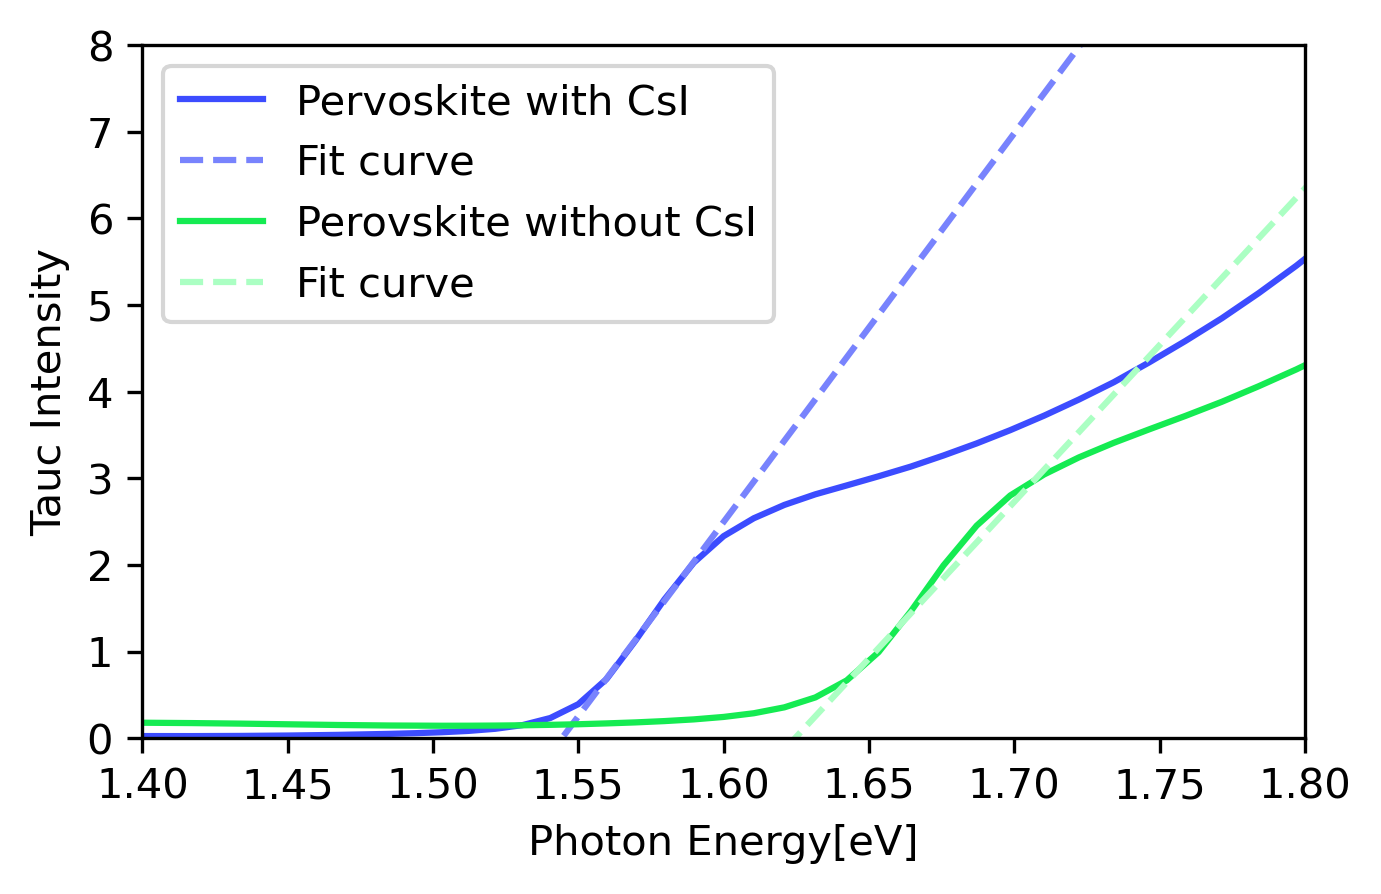

In [42]:
#Closeup, use this to demostrate
plt.figure(figsize = (5, 3), dpi = 300)
plt.plot(eV, tauc_intensity_with, color = colors[0], label = labels[0])
plt.plot(eV, eV * tauc_fit_with["slope"] + tauc_fit_with['intercept'], linestyle='--', color = colors_fit[0], label = f"Fit curve")
plt.plot(eV, tauc_intensity_without, color = colors[1], label = labels[1])
plt.plot(eV, eV * tauc_fit_without["slope"] + tauc_fit_without['intercept'], linestyle='--', color = colors_fit[1], label = f"Fit curve")
plt.ylim(0, 8)
plt.xlim(1.4, 1.8)
plt.xlabel("Photon Energy[eV]")
plt.ylabel("Tauc Intensity")
plt.legend()
#plt.grid()

### Linear Regression for the Urbach Energy

In [43]:
tauc_ln = np.log(tauc_intensity)

(-4.0, 2.0)

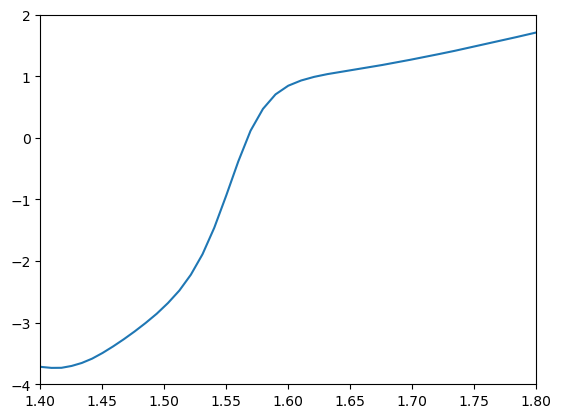

In [44]:
#Quick Plot:
plt.plot(eV, tauc_ln)
plt.xlim(1.4, 1.8)
plt.ylim(-4, 2)

In [45]:
urbach_x = eV.reshape(-1, 1)
urbach_y = tauc_ln.reshape(-1, 1)
mask_urbach = (urbach_x > 1.53) & (urbach_x < 1.56)
urbach_x_selected = urbach_x[mask_urbach].reshape(-1, 1)
urbach_y_selected = urbach_y[mask_urbach].reshape(-1, 1)


In [46]:
print("Tauc")
print(x_selected)
print(y_selected)
print("Urbach")
print(urbach_x_selected)
print(urbach_y_selected)

Tauc
[[1.56962025]
 [1.57961783]
 [1.58974359]]
[[1.12299918]
 [1.60063421]
 [2.02591135]]
Urbach
[[1.5308642 ]
 [1.54037267]
 [1.55      ]
 [1.55974843]]
[[-1.88972058]
 [-1.45829518]
 [-0.93600263]
 [-0.38148119]]


In [47]:
urbach_fit = LinearRegression().fit(urbach_x_selected, urbach_y_selected)

urbach_slope = urbach_fit.coef_[0, 0]
urbach_intercept = urbach_fit.intercept_[0]
urbach_r_squared = urbach_fit.score(x_selected, y_selected)
urbach_x_intercept = -urbach_intercept / urbach_slope
print(f"Slope: {urbach_slope:.4f}")
print(f"Intercept: {urbach_intercept:.4f}")
print(f"R^2: {urbach_r_squared:.4f}")
print(f"Urbach gap (x-intercept): {urbach_x_intercept:.4f} eV")
Urbach_Energy = 1/ urbach_slope


Slope: 52.4344
Intercept: -82.1905
R^2: -5.5958
Urbach gap (x-intercept): 1.5675 eV


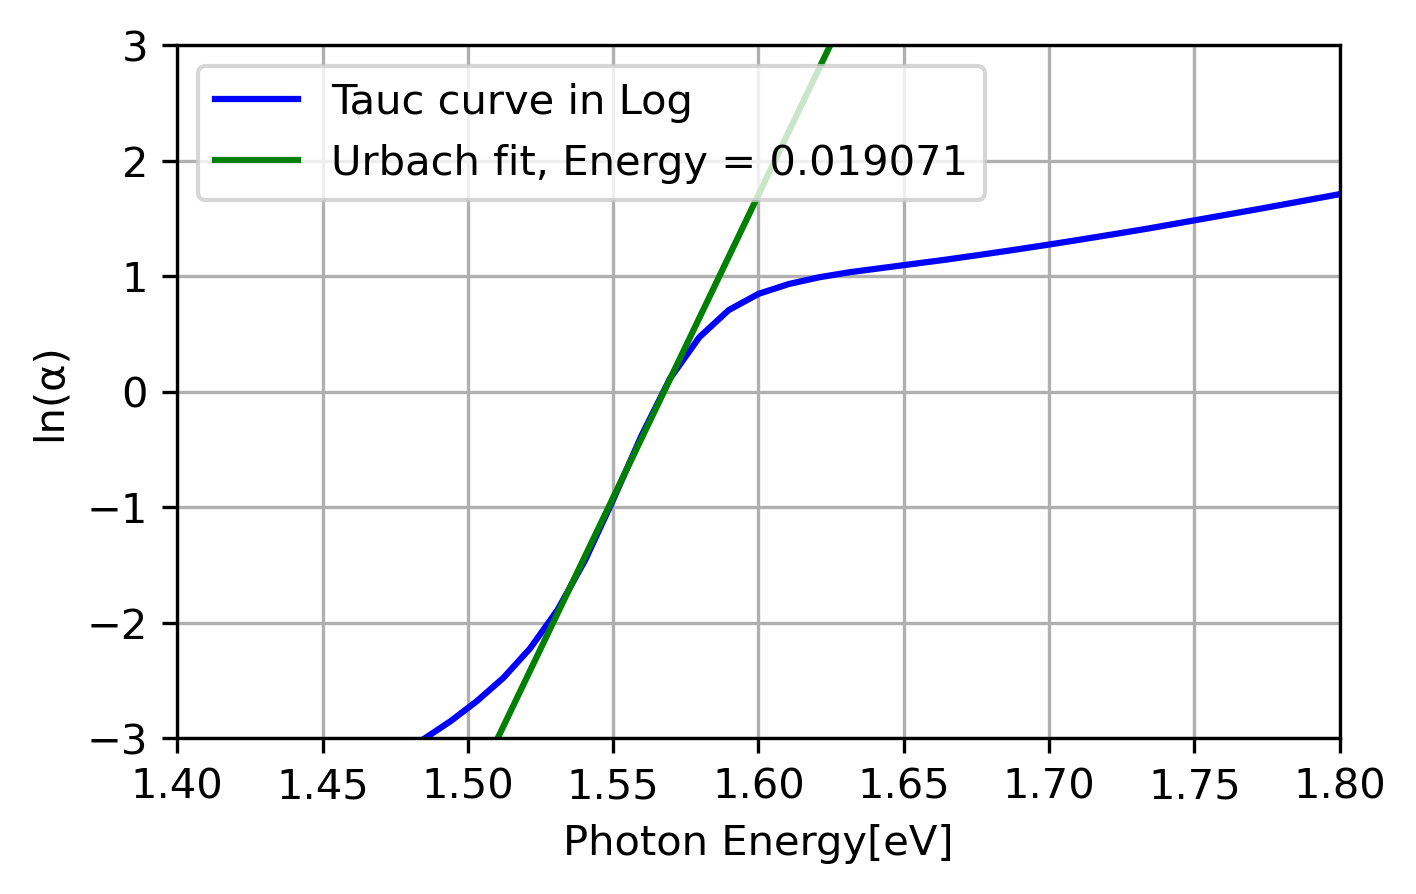

In [48]:
plt.figure(figsize=(5, 3), dpi = 300)
plt.plot(eV, tauc_ln, color = "blue", label = "Tauc curve in Log")
#plt.plot(eV, np.log(eV * tauc_slope + tauc_intercept), color = "orange", label = f"Tauc Fit, band gap = {urbach_x_intercept:2f}")
plt.plot(eV, (eV * urbach_slope + urbach_intercept), color = "green", label = f"Urbach fit, Energy = {Urbach_Energy:2f}")
plt.xlim(1.4, 1.8)
plt.ylim(-3, 3)
plt.xlabel("Photon Energy[eV]")
plt.ylabel("ln(α)")
plt.legend()
plt.grid()

### Do the original plot with urbach fit

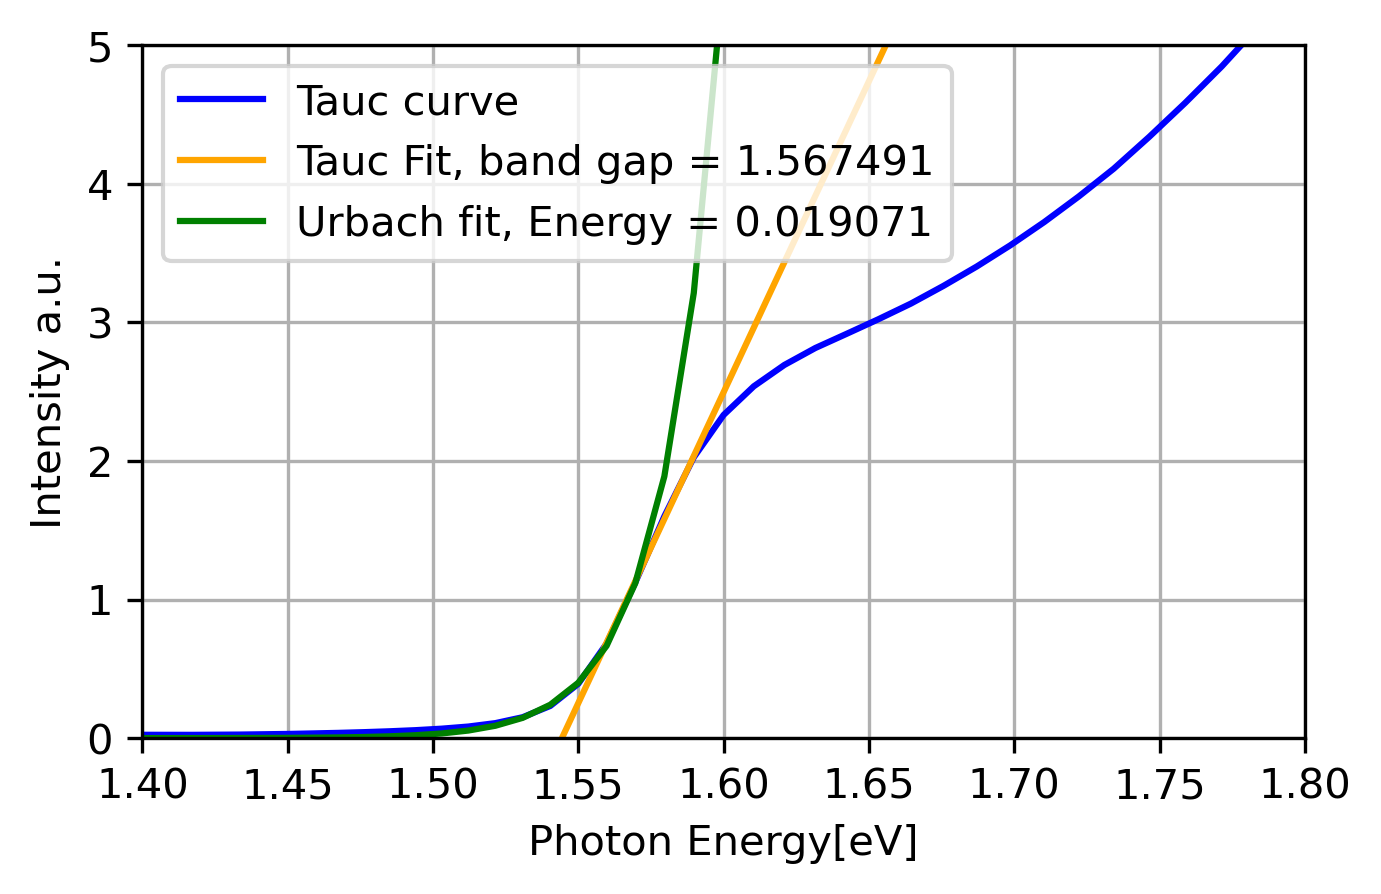

In [49]:
plt.figure(figsize=(5, 3), dpi = 300)
plt.plot(eV, tauc_intensity, color = "blue", label = "Tauc curve")
plt.plot(eV, (eV * tauc_slope + tauc_intercept), color = "orange", label = f"Tauc Fit, band gap = {urbach_x_intercept:2f}")
plt.plot(eV, np.exp(eV * urbach_slope + urbach_intercept), color = "green", label = f"Urbach fit, Energy = {Urbach_Energy:2f}")
plt.xlim(1.4, 1.8)
plt.ylim(0, 5)
plt.xlabel("Photon Energy[eV]")
plt.ylabel("Intensity a.u.")
plt.legend()
plt.grid()

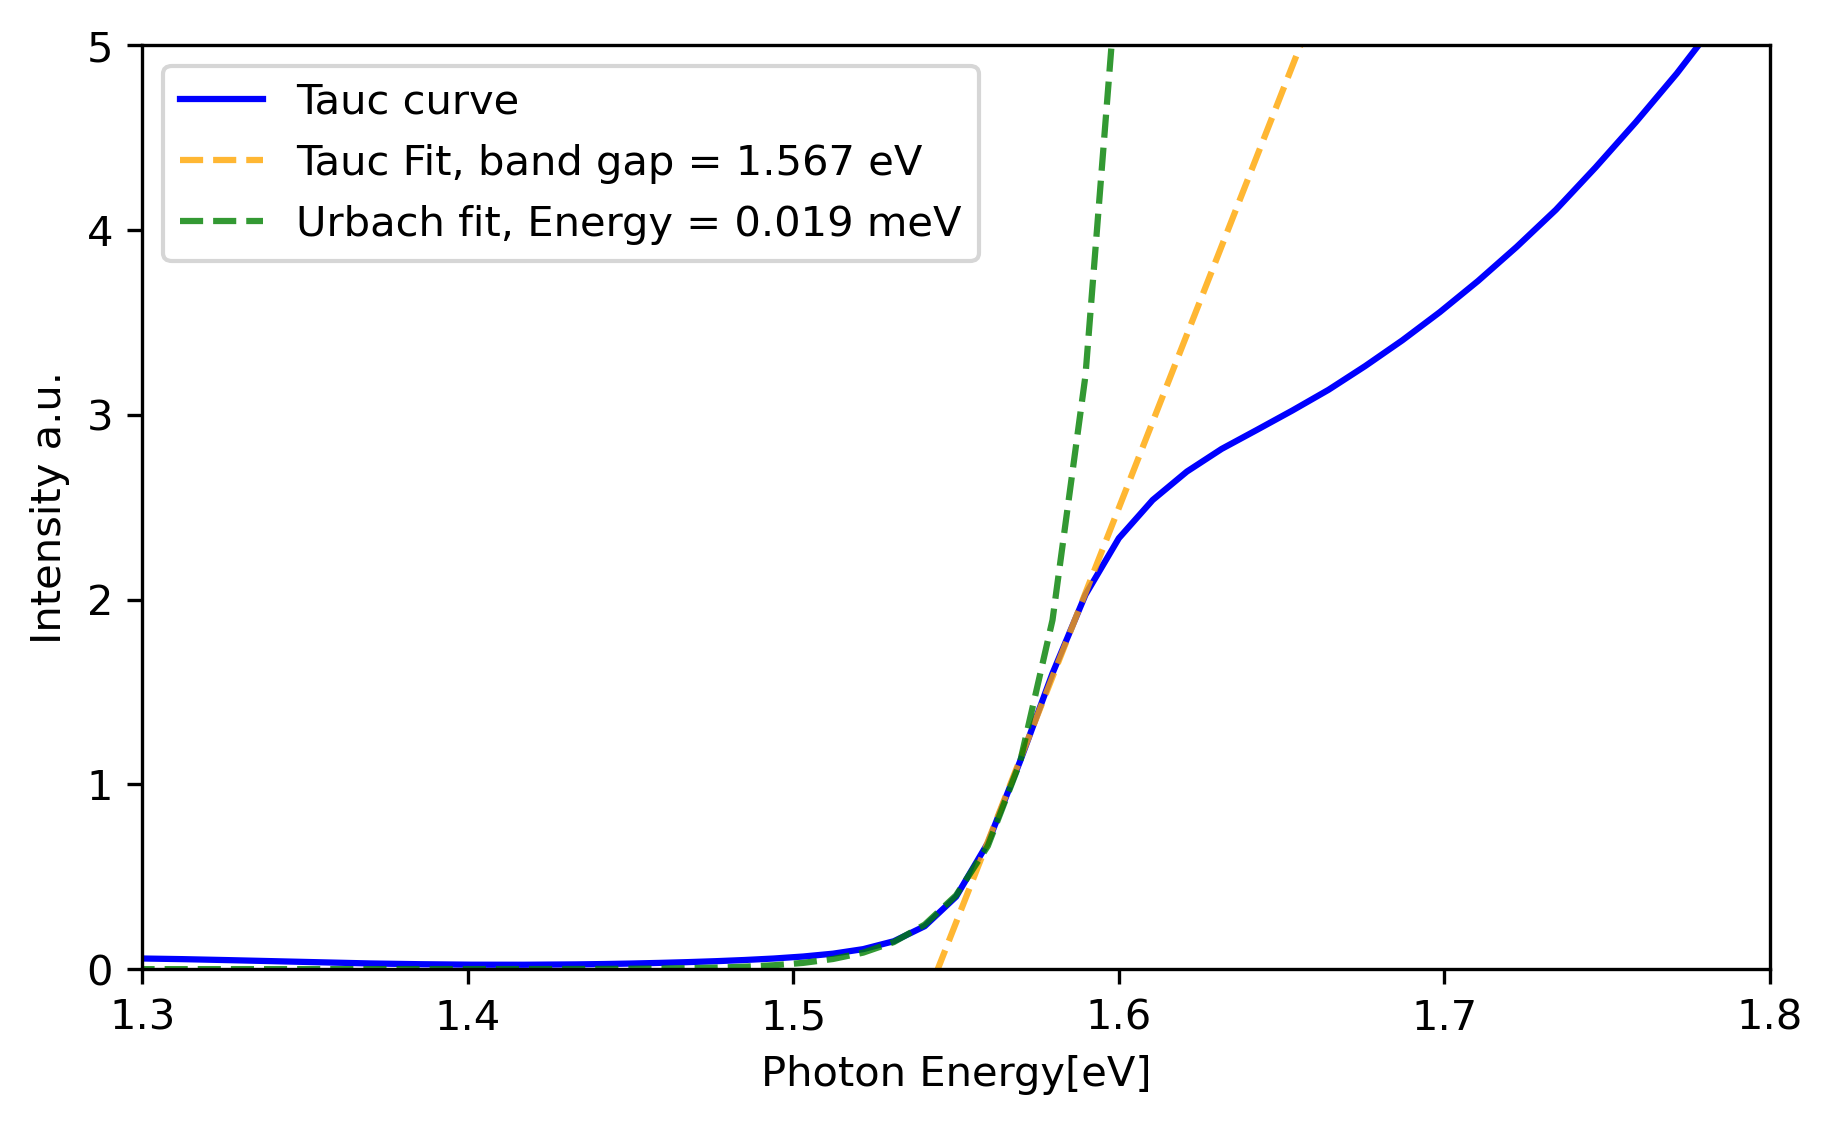

In [71]:
plt.figure(figsize=(7, 4), dpi = 300)
plt.plot(eV, tauc_intensity, color = "blue", label = "Tauc curve")
plt.plot(
    eV,
    (eV * tauc_slope + tauc_intercept),
    color="orange",
    alpha = 0.8,
    linestyle='--',
    label=f"Tauc Fit, band gap = {urbach_x_intercept:.3f} eV"
)

plt.plot(
    eV,
    np.exp(eV * urbach_slope + urbach_intercept),
    color="green",
    alpha = 0.8,
    linestyle='--',
    label=f"Urbach fit, Energy = {Urbach_Energy:.3f} meV"
)
plt.xlim(1.3, 1.8)
plt.ylim(0, 5)
plt.xlabel("Photon Energy[eV]")
plt.ylabel("Intensity a.u.")
plt.legend()
#plt.grid()

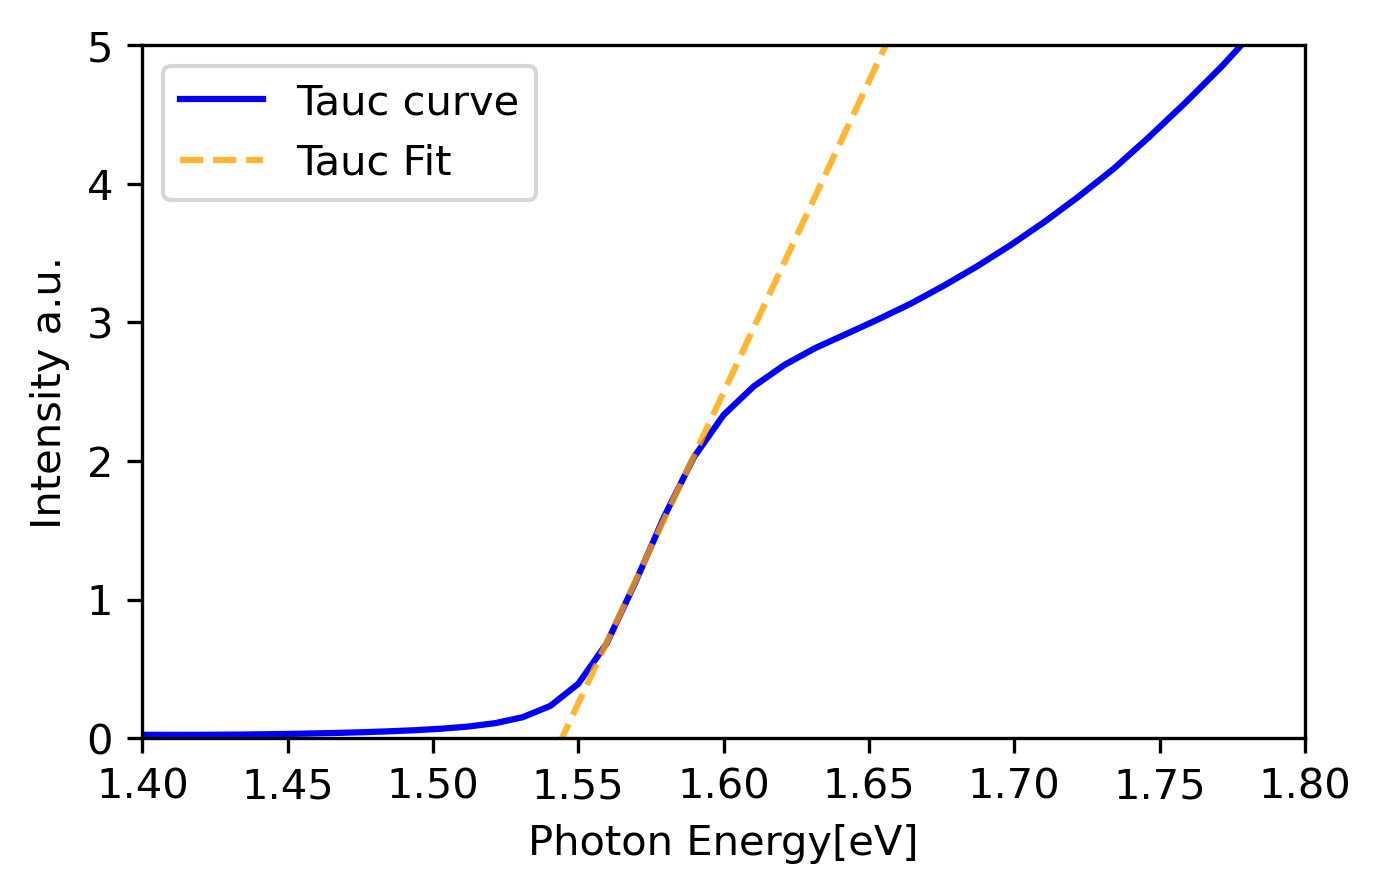

In [70]:
plt.figure(figsize=(5, 3), dpi = 300)
plt.plot(eV, tauc_intensity, color = "blue", label = "Tauc curve")
plt.plot(
    eV,
    (eV * tauc_slope + tauc_intercept),
    color="orange",
    alpha = 0.8,
    linestyle='--',
    label=f"Tauc Fit"
)
plt.xlim(1.4, 1.8)
plt.ylim(0, 5)
plt.xlabel("Photon Energy[eV]")
plt.ylabel("Intensity a.u.")
plt.legend()
#plt.grid()